In [1]:
#Single Agent environment 

from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv()
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()




<class 'type'>
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [2]:
#Baseline CGR

done=False
total_reward=0
while not done:
    

    # Choose an action manually
    action = 1

    # Take the action
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Observation: {obs}")
    done = terminated or truncated
    total_reward += reward

    print(f"Reward: {reward}, Done: {done}")

env.close()
print(f"Total reward: {total_reward}")



Observation: {'contact plan': array([0.7, 0.1, 0.2, 0.2, 0.2, 0.8, 0.9, 0.3, 0.8, 0.9], dtype=float32), 'Remaining data': array([0.], dtype=float32), 'current timestep': array([2.], dtype=float32)}
Reward: 18.666667938232422, Done: True
Total reward: 18.666667938232422


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/bin/python


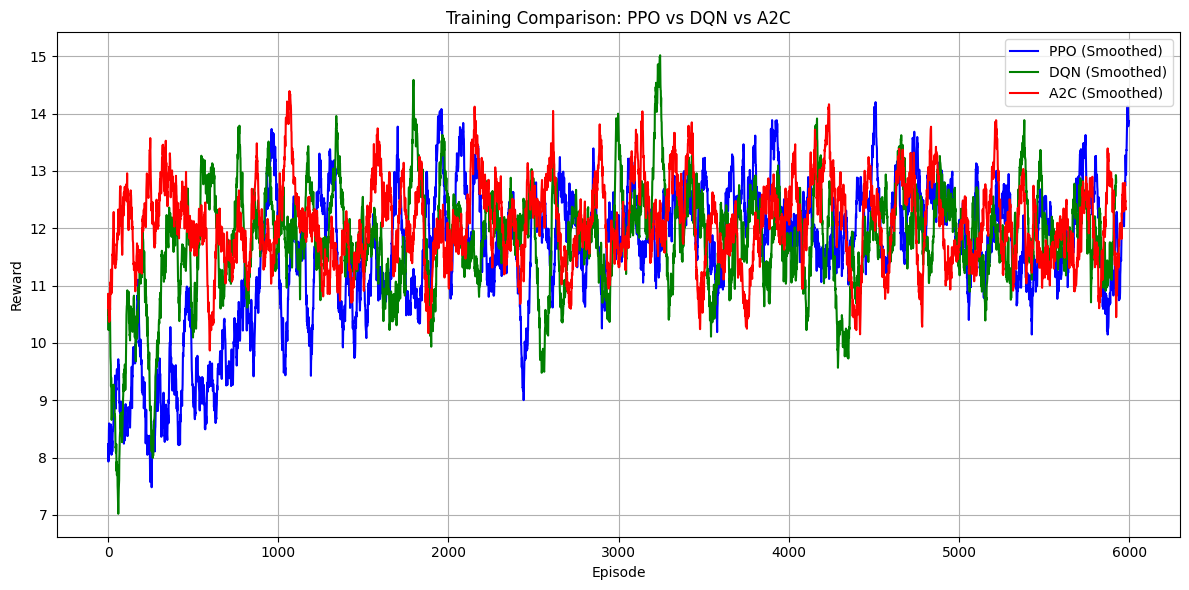

In [12]:
#Setup Stable Baseline3 Agents
import sys
import numpy as np
print(sys.executable)
import stable_baselines3
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check if episode info is available
        info = self.locals.get("infos", [{}])[0]
        if "episode" in info:
            reward = info["episode"]["r"]
            self.episode_rewards.append(reward)
        return True



def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
def train_agent(agent_class, env_id, total_timesteps=50000):
    env = Monitor(SingleSatelliteEnv())
    model = agent_class("MultiInputPolicy", env, verbose=0)
    logger = RewardLogger()
    model.learn(total_timesteps=total_timesteps, callback=logger)
    return logger.episode_rewards, model


ppo_rewards,ppo_model = train_agent(PPO, env)
dqn_rewards,dqn_model = train_agent(DQN, env)
a2c_rewards,a2c_model = train_agent(A2C, env)


# Smoothed rewards
#smoothed_rewards = moving_average(rewards, window_size=50)

# Plotting
plt.figure(figsize=(12, 6))

# Raw (optional)
# plt.plot(ppo_rewards, label='PPO Raw', alpha=0.3)
# plt.plot(dqn_rewards, label='DQN Raw', alpha=0.3)
# plt.plot(a2c_rewards, label='A2C Raw', alpha=0.3)

# Smoothed
plt.plot(moving_average(ppo_rewards, 50), label='PPO (Smoothed)', color='blue')
plt.plot(moving_average(dqn_rewards, 50), label='DQN (Smoothed)', color='green')
plt.plot(moving_average(a2c_rewards, 50), label='A2C (Smoothed)', color='red')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Comparison: PPO vs DQN vs A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
ppo_mean, ppo_std = evaluate_policy(ppo_model, Monitor(env), n_eval_episodes=100, render=False)

# Evaluate DQN
dqn_mean, dqn_std = evaluate_policy(dqn_model, Monitor(env), n_eval_episodes=100, render=False)

# Evaluate A2C
a2c_mean, a2c_std = evaluate_policy(a2c_model, Monitor(env), n_eval_episodes=100, render=False)

print(f"PPO Mean Reward: {ppo_mean:.2f} ± {ppo_std:.2f}")
print(f"DQN Mean Reward: {dqn_mean:.2f} ± {dqn_std:.2f}")
print(f"A2C Mean Reward: {a2c_mean:.2f} ± {a2c_std:.2f}")

PPO Mean Reward: 12.22 ± 5.11
DQN Mean Reward: 11.30 ± 4.81
A2C Mean Reward: 11.35 ± 5.42


In [14]:
obs, _ = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated


NameError: name 'model' is not defined

In [15]:
#Need to make graphs and compare the different Stable baseline3 agents to the
#Heuristics
initial_observation,initial_information=env.reset()
print("Initial Observation")
print(initial_observation)

Initial Observation
{'contact plan': array([0.8, 0.1, 0.5, 0.6, 0.8, 0.4, 0. , 0.3, 0.5, 0.2], dtype=float32), 'Remaining data': array([0.06], dtype=float32), 'current timestep': array([0.], dtype=float32)}


In [24]:
#Implement sorting algorithm
initial_data_volume=initial_observation["Remaining data"]*100
contacts_available=initial_observation["contact plan"]
sorted_matrix=np.zeros([10,2])
current_contact_iterator=0
#Next we must calculate the initial allocation of contacts
j=0
for i in contacts_available:
    sorted_matrix[j,0]=i
    sorted_matrix[j,1]=j
    j=j+1
sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
remaining_data=initial_data_volume
decision_matrix=np.zeros(10)
j=0
for i in decision_matrix:
    if (remaining_data>0):
        if sorted_matrix[j,0]<1:
            remaining_data=remaining_data-sorted_matrix[j,0]*10
            i=1
    j=j+1
i=0
done=False
while not done:
    print(i)
    if decision_matrix[i]==0:
        #We don't use this contact
        action=0
        next_obs, reward, terminated, truncated, info = env.step(action)
    else:
        #We use the contact
        action=1
        next_obs, reward, terminated, truncated, info = env.step(action)
        #Next we need to determine if we successfully delivered any packets
        current_delivered=next_obs["Remaining data"]
        previous_delivered=obs["Remaining data"]
        if (current_delivered>previous_delivered):
            #We need to recalculate the decision matrix
            remaining_data=current_delivered*100
            aux_sorting_matrix=np.zeros([10,2])
            for j in range(0,9):
                aux_sorting_matrix[j,0]=contacts_available[j]
                aux_sorting_matrix[j,1]=j
            for j in range(0,i):
                aux_sorting_matrix[j,0]=1
                
            aux_sorting_matrix=aux_sorted_matrix[aux_sorted_matrix[:, 0].argsort()]
            decision_matrix=np.zeros(10)
            k=0
            for j in decision_matrix:
                if remaining_data>0:
                    if aux_sorted_matrix[k,0]<1:
                        remaining_data=remaining_data-aux_sorted_matrix[k,0]*10
                        i=1
                k=k+1
    obs=next_obs
    i=i+1
    if terminated==False and truncated==False:
        done=False
    else:
        done=True
#Next we need to graph and log the results of the heuristic algorithm
env.close()
print(f"Total reward: {total_reward}")




#Setup CleanRL Agents

0
Total reward: 18.666667938232422


In [ ]:
#Evaluation Code
#Here we take results obtained from the different agents and we plot the reward curves
#And we evaluate the delivery ratio and the energy efficiency for the different results
# We will start by comparing the CGR and Sorting Heuristic





